# F1 — Sınıflandırma ve Kümeleme

Bu notebook iki bölümden oluşuyor:

**Bölüm A — Sınıflandırma (lojistik regresyon).**
Soru: Yarış öncesi bilgiyle podyum tahmin edilebilir mi? Mevcut
"grid ≤ 3 ise podyum" kuralımızı geçebilir miyiz?

**Bölüm B — Kümeleme (K-Means ve DBSCAN).**
Soru: Pistler kendiliğinden gruplara ayrılıyor mu? H4'te Monaco ile Monza'yı
elle karşılaştırmıştık — algoritma bu ayrımı biz söylemeden bulabiliyor mu?

Aradaki fark: Bölüm A'da doğru cevabı biliyoruz ve modele öğretiyoruz
(**denetimli öğrenme**). Bölüm B'de doğru cevap diye bir şey yok, algoritma
veriden yapı çıkarıyor (**denetimsiz öğrenme**).

## Kurulum

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score,
    r2_score, mean_absolute_error,
)

PROJECT_ID = "f1-analytics-505812"
client = bigquery.Client(project=PROJECT_ID)

---
# BÖLÜM A — Sınıflandırma

## A1. Veri

Modele **yalnızca yarış başlamadan bilinen** bilgiyi veriyoruz.

Bilerek almadığımız sütunlar: `position_order`, `points`, `is_dnf`,
`status_group`, `teammate_finish_gap`. Bunlar yarış bittikten sonra belli oluyor.
Modele koyarsak mükemmel skor alırız ama hiçbir şey öğrenmiş olmayız — buna
**veri sızıntısı** deniyor.

Kapsam 1983–2024. Hipotez testlerinde 2003 sonrasını kullanmıştık çünkü takım
arkadaşı qualifying karşılaştırması gerekiyordu; model bunu kullanmıyor.

In [ ]:
query = """
SELECT
    race_id, season_year,
    grid_position,
    team_form_5_pos,
    driver_form_5_pos,
    form_race_count,
    is_podium,
    position_order,
    is_classified
FROM `f1_analytics.int_pre_race_features`
WHERE season_year BETWEEN 1983 AND 2024
"""

ham = client.query(query, location="EU").to_dataframe()

# form_race_count >= 5: form metrigi son 5 yarisin ortalamasi.
# Sezon basinda bu pencere dolmadigi icin o kayitlari disariyoruz.
d = ham[ham["form_race_count"] >= 5].copy()
d = d.dropna(subset=["grid_position", "team_form_5_pos", "driver_form_5_pos"])

y = d["is_podium"].astype(int)

print(f"Modellenebilir kayit: {len(d)}")
print(f"Podyum orani: %{y.mean()*100:.1f}")

Modellenebilir kayit: 11998
Podyum orani: %13.5


## A2. Eğitim ve test

Modeli eski yarışlarda eğitip yeni yarışlarda sınıyoruz. Rastgele bölmüyoruz —
zaman serisinde rastgele bölmek, modelin 2024 yarışlarını görüp 2010 yarışlarını
tahmin etmesi demek olurdu.

In [ ]:
egitim = d["season_year"] <= 2016
test = d["season_year"] >= 2017

for ad, maske in [("Egitim", egitim), ("Test", test)]:
    print(f"{ad:7s} {maske.sum():5d} kayit | "
          f"{d.loc[maske,'season_year'].min()}-{d.loc[maske,'season_year'].max()} | "
          f"podyum orani %{y[maske].mean()*100:.1f}")

Egitim   9467 kayit | 1983-2016 | podyum orani %13.0
Test     2531 kayit | 2017-2024 | podyum orani %15.3


## A3. Üç model

Amaç sadece en iyi modeli bulmak değil, **hangi bilginin ne kadar işe yaradığını**
görmek.

**Ölçeklendirme neden gerekli?** `grid_position` ve form değişkenleri farklı
dağılıyor. `StandardScaler` hepsini ortalaması 0, standart sapması 1 olacak
şekilde dönüştürüyor. Böylece katsayıları birbiriyle karşılaştırabiliyoruz.

In [ ]:
SETLER = {
    "Sadece grid": ["grid_position"],
    "Sadece form": ["team_form_5_pos", "driver_form_5_pos"],
    "Grid + form": ["grid_position", "team_form_5_pos", "driver_form_5_pos"],
}

modeller = {}
for ad, ozellikler in SETLER.items():
    olcek = StandardScaler().fit(d.loc[egitim, ozellikler])
    model = LogisticRegression(max_iter=1000)
    model.fit(olcek.transform(d.loc[egitim, ozellikler]), y[egitim])

    # predict_proba -> her satir icin "podyum yapma olasiligi"
    olasilik = model.predict_proba(olcek.transform(d.loc[test, ozellikler]))[:, 1]
    modeller[ad] = {"model": model, "ozellikler": ozellikler, "olasilik": olasilik}

print("Uc model egitildi.")

Uc model egitildi.


## A4. Karşılaştırma

| Metrik | Sorusu |
|---|---|
| **Precision** | "Podyum yapar" dediklerimin kaçı gerçekten podyum yaptı? |
| **Recall** | Gerçek podyumların kaçını yakalayabildim? |
| **F1** | Precision ve recall'un dengesi |
| **Accuracy** | Toplam kaç tahminim doğru? |

Karşılaştırmaya iki referans ekliyoruz: mevcut baseline kuralımız ve hiçbir şey
tahmin etmeyen model.

In [ ]:
def olc(ad, gercek, tahmin):
    return {
        "Model": ad,
        "Precision": round(precision_score(gercek, tahmin, zero_division=0) * 100, 1),
        "Recall": round(recall_score(gercek, tahmin, zero_division=0) * 100, 1),
        "F1": round(f1_score(gercek, tahmin, zero_division=0) * 100, 1),
        "Accuracy": round(accuracy_score(gercek, tahmin) * 100, 1),
    }

satirlar = [olc(ad, y[test], (m["olasilik"] >= 0.5).astype(int))
            for ad, m in modeller.items()]

baseline = d.loc[test, "grid_position"].le(3).astype(int)
satirlar.append(olc("Baseline (grid<=3)", y[test], baseline))
satirlar.append(olc("Hicbiri podyum degil", y[test], np.zeros(test.sum(), dtype=int)))

print(pd.DataFrame(satirlar).to_string(index=False))

               Model  Precision  Recall   F1  Accuracy
         Sadece grid       74.2    49.1 59.1      89.6
         Sadece form       56.6    41.9 48.1      86.2
         Grid + form       69.1    61.2 64.9      89.9
  Baseline (grid<=3)       67.2    66.7 66.9      89.9
Hicbiri podyum degil        0.0     0.0  0.0      84.7


### Bu tablonun okunuşu

**Accuracy'ye kanma.** "Hiçbiri podyum değil" diyen model bile yüksek accuracy
alıyor, çünkü kayıtların büyük çoğunluğu zaten podyum değil. Bir model bu satırdan
belirgin şekilde yüksek değilse gerçek iş yapmıyor demektir.

**Sadece form modeli neden zayıf?** Takımın ve sürücünün genel gücünü biliyor ama
o yarışta nereden başladığını bilmiyor.

**Grid + form neden en iyi?** Grid omurga, form ince ayar.

## A5. Karar eşiği

Model her satır için bir **olasılık** üretiyor. Bunu "evet/hayır"a çevirmek için
bir eşik gerekiyor. Varsayılan 0,5 — ama bu, iki sınıfın eşit sıklıkta olduğunu
varsayar. Bizde podyum çok daha nadir.

Eşiği düşürmek modeli cesaretlendiriyor: daha çok gerçek podyum yakalıyor
(**recall artıyor**) ama daha çok yanlış alarm veriyor (**precision düşüyor**).

In [ ]:
en_iyi = modeller["Grid + form"]

satirlar = []
for esik in [0.50, 0.45, 0.40, 0.35, 0.30]:
    tahmin = (en_iyi["olasilik"] >= esik).astype(int)
    satir = olc(f"esik = {esik:.2f}", y[test], tahmin)
    satir["Kac kez podyum dedi"] = int(tahmin.sum())
    satirlar.append(satir)

print(pd.DataFrame(satirlar).to_string(index=False))
print(f"\nTest setindeki gercek podyum sayisi: {int(y[test].sum())}")

      Model  Precision  Recall   F1  Accuracy  Kac kez podyum dedi
esik = 0.50       69.1    61.2 64.9      89.9                  343
esik = 0.45       66.8    69.3 68.0      90.0                  401
esik = 0.40       62.5    76.2 68.7      89.4                  472
esik = 0.35       58.3    81.9 68.1      88.3                  544
esik = 0.30       54.9    85.3 66.8      87.0                  601

Test setindeki gercek podyum sayisi: 387


F1'i en yükseğe çıkaran eşiği aşağıya yaz.

**Dürüst not:** Eşiği test setine bakarak seçmek kusurlu bir yöntemdir — kendi
sınavının sorularını görmüş olursun. Doğrusu ayrı bir doğrulama seti kullanmak.
Bu iterasyonda basitlik için tek bölme kullandık; sorulursa bunu bildiğini söyle.

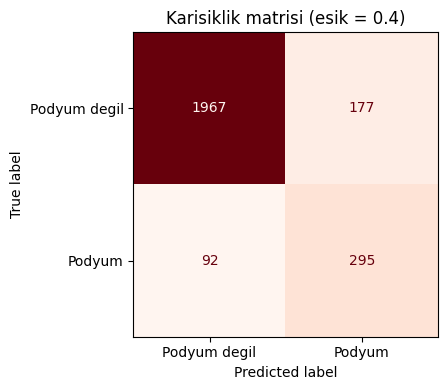

Dogru yakalanan podyum : 295
Kacirilan podyum       : 92
Yanlis alarm           : 177
Dogru elenen           : 1967


In [ ]:
SECILEN_ESIK = 0.40   # yukaridaki tabloya bakip guncelle

tahmin = (en_iyi["olasilik"] >= SECILEN_ESIK).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y[test], tahmin, display_labels=["Podyum degil", "Podyum"],
    cmap="Reds", ax=ax, colorbar=False)
ax.set_title(f"Karisiklik matrisi (esik = {SECILEN_ESIK})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y[test], tahmin).ravel()
print(f"Dogru yakalanan podyum : {tp}")
print(f"Kacirilan podyum       : {fn}")
print(f"Yanlis alarm           : {fp}")
print(f"Dogru elenen           : {tn}")

## A6. Katsayılar

Katsayılar özelliklerin ağırlığını gösteriyor.

**İşaretler neden negatif?** Çünkü bu üç değişken de **küçükken iyi**: grid 1 en
iyi başlangıç, form 2,5 çok güçlü bir takım demek. Sayı büyüdükçe podyum ihtimali
düşüyor, o yüzden katsayı negatif.

İşarete değil, **mutlak büyüklüğe** bak.

grid_position       -2.182
team_form_5_pos     -0.383
driver_form_5_pos   -0.463


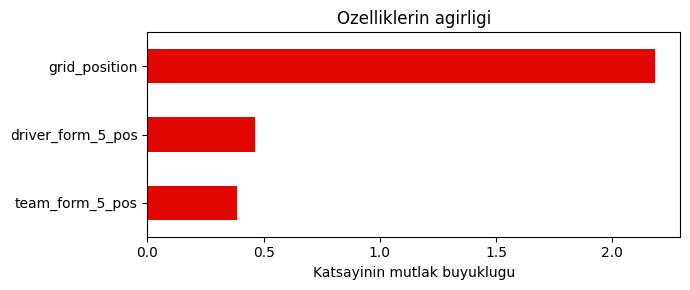

In [ ]:
katsayilar = pd.Series(en_iyi["model"].coef_[0], index=en_iyi["ozellikler"])
print(katsayilar.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3))
katsayilar.abs().sort_values().plot(kind="barh", color="#E10600", ax=ax)
ax.set_xlabel("Katsayinin mutlak buyuklugu")
ax.set_title("Ozelliklerin agirligi")
plt.tight_layout(); plt.show()

## A7. Lineer regresyon — kaçıncı bitirir?

Sınıflandırma "podyum yapar mı" diye sordu. Regresyon daha zorunu soruyor:
**kaçıncı sırada bitirir?** Yalnızca yarışı bitirenlerle çalışıyoruz.

In [ ]:
bit = d[d["is_classified"]].copy()
y_reg = bit["position_order"]
reg_egitim = bit["season_year"] <= 2016
reg_test = bit["season_year"] >= 2017

for ad, ozellikler in [("Sadece grid", ["grid_position"]),
                       ("Grid + form", ["grid_position", "team_form_5_pos",
                                        "driver_form_5_pos"])]:
    lin = LinearRegression().fit(bit.loc[reg_egitim, ozellikler], y_reg[reg_egitim])
    tahmin_reg = lin.predict(bit.loc[reg_test, ozellikler])
    print(f"{ad:14s} R2 = {r2_score(y_reg[reg_test], tahmin_reg):.3f} | "
          f"ortalama hata = {mean_absolute_error(y_reg[reg_test], tahmin_reg):.2f} sira")

Sadece grid    R2 = 0.436 | ortalama hata = 2.96 sira
Grid + form    R2 = 0.485 | ortalama hata = 2.77 sira


**Dikkat: iki farklı sayı.** Sunumda "grid sonucun %58'ini açıklıyor" diyoruz.
Burada daha düşük bir R² göreceksin. %58 geçmiş veriye bakarak hesaplanan
korelasyonun karesi; buradaki R² ise modelin **hiç görmediği** yarışlardaki
performansı. Geçmişi açıklamak, geleceği tahmin etmekten her zaman kolaydır.

---
# BÖLÜM B — Kümeleme

Buraya kadar modele doğru cevabı söyledik. Şimdi söylemiyoruz.

**Soru:** Pistleri dört özellikleriyle tanımlayıp algoritmaya versek, kendiliğinden
gruplara ayırır mı? Ve bu gruplar bizim H4'te elle bulduğumuz ayrımla örtüşür mü?

H4'te şunu bulmuştuk: Monaco ile Monza'nın öngörülebilirliği neredeyse aynı
(0,761 ve 0,760) ama mekanizmaları taban tabana zıt — Monaco'da kaza oranı %13,9,
Monza'da %4,5. Bu ayrımı biz gözle bulduk. Algoritma da bulacak mı?

## B1. Veri ve ölçeklendirme

**Ölçeklendirme kümelemede neden zorunlu?** K-Means noktalar arası **uzaklık**
hesaplıyor. `kaza_orani` 3–14 arasında, `grid_finish_korelasyon` 0,65–0,87
arasında değişiyor. Ölçeklemezsek kaza oranı uzaklık hesabına tek başına
hükmeder, korelasyon hiç sayılmaz.

In [ ]:
pist = client.query("""
SELECT circuit_name, yaris_sayisi,
       grid_finish_korelasyon,
       kaza_orani,
       dnf_orani,
       ort_pozisyon_degisimi
FROM `f1_analytics.mart_circuit_stats`
WHERE yaris_sayisi >= 6
""", location="EU").to_dataframe()

OZ = ["grid_finish_korelasyon", "kaza_orani", "dnf_orani", "ort_pozisyon_degisimi"]

print(f"{len(pist)} pist, {len(OZ)} ozellik\n")
print("Olcekleme ONCESI degisim araliklari:")
print(pist[OZ].describe().loc[["min", "max"]].round(2).to_string())

X = StandardScaler().fit_transform(pist[OZ].astype(float))

print("\nOlcekleme SONRASI:")
print(pd.DataFrame(X, columns=OZ).describe().loc[["mean", "std"]].round(2).to_string())

25 pist, 4 ozellik

Olcekleme ONCESI degisim araliklari:
     grid_finish_korelasyon  kaza_orani  dnf_orani  ort_pozisyon_degisimi
min                    0.65         3.2       14.9                   2.94
max                    0.87        13.9       33.0                   4.58

Olcekleme SONRASI:
      grid_finish_korelasyon  kaza_orani  dnf_orani  ort_pozisyon_degisimi
mean                    0.00        0.00      -0.00                  -0.00
std                     1.02        1.02       1.02                   1.02


## B2. Elbow yöntemi — kaç küme?

K-Means'e kaç küme istediğimizi biz söylemek zorundayız. Elbow yöntemi buna
karar vermenin standart yolu.

**Inertia** nedir: her noktanın kendi küme merkezine uzaklığının karelerinin
toplamı. Küme sayısı arttıkça inertia hep düşer — k sayısı nokta sayısına
eşit olsa inertia sıfır olur. O yüzden "en düşük inertia" diye bir hedef yok.

Aradığımız şey **dirsek**: inertia'nın hızlı düşmeyi bırakıp yatay seyre geçtiği
nokta. O noktadan sonra küme eklemek pek bir şey kazandırmıyor demektir.

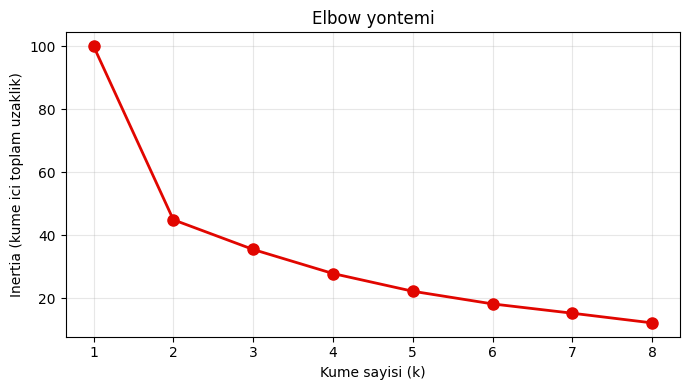

k'dan k+1'e gecince inertia dususu:
  1 -> 2: %55.1
  2 -> 3: %21.0
  3 -> 4: %21.5
  4 -> 5: %20.2
  5 -> 6: %18.1
  6 -> 7: %16.2
  7 -> 8: %20.1


In [ ]:
inertia = []
K = range(1, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K), inertia, "o-", color="#E10600", linewidth=2, markersize=8)
ax.set_xlabel("Kume sayisi (k)")
ax.set_ylabel("Inertia (kume ici toplam uzaklik)")
ax.set_title("Elbow yontemi")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Her adimda inertia yuzde kac dustu?
print("k'dan k+1'e gecince inertia dususu:")
for i in range(1, len(inertia)):
    dusus = (inertia[i-1] - inertia[i]) / inertia[i-1] * 100
    print(f"  {i} -> {i+1}: %{dusus:.1f}")

Yüzde tablosuna bak: ilk adımda büyük bir düşüş var, sonrasında düşüşler
birbirine yakın ve küçük. Dirsek orada.

Aşağıda o k değerini yaz.

In [ ]:
SECILEN_K = 2   # elbow grafigine bakip guncelle

km = KMeans(n_clusters=SECILEN_K, random_state=42, n_init=10)
pist["kume"] = km.fit_predict(X)

profil = pist.groupby("kume")[OZ].mean().round(2)
profil["pist_sayisi"] = pist.groupby("kume").size()
print("Kume profilleri (ortalamalar):")
print(profil.to_string())

print("\nKume uyeleri:")
for k in sorted(pist["kume"].unique()):
    isimler = pist.loc[pist["kume"] == k, "circuit_name"].tolist()
    print(f"\n  Kume {k} ({len(isimler)} pist):")
    for isim in isimler:
        print(f"    - {isim}")

Kume profilleri (ortalamalar):
      grid_finish_korelasyon  kaza_orani  dnf_orani  ort_pozisyon_degisimi  pist_sayisi
kume                                                                                   
0                       0.78        5.66      17.78                   3.58           14
1                       0.71        9.99      23.88                   4.25           11

Kume uyeleri:

  Kume 0 (14 pist):
    - Circuit de Nevers Magny-Cours
    - Autodromo Enzo e Dino Ferrari
    - Autódromo Hermanos Rodríguez
    - Istanbul Park
    - Circuit of the Americas
    - Red Bull Ring
    - Yas Marina Circuit
    - Shanghai International Circuit
    - Suzuka Circuit
    - Bahrain International Circuit
    - Circuit de Barcelona-Catalunya
    - Hungaroring
    - Autodromo Nazionale di Monza
    - Silverstone Circuit

  Kume 1 (11 pist):
    - Baku City Circuit
    - Sochi Autodrom
    - Nürburgring
    - Hockenheimring
    - Marina Bay Street Circuit
    - Sepang International Circu

## B3. Asıl soru: Monaco ve Monza ayrıldı mı?

In [ ]:
for isim in ["Monaco", "Monza"]:
    satir = pist[pist["circuit_name"].str.contains(isim)]
    print(f"{isim:8s} kume={satir['kume'].iloc[0]} | "
          f"ongorulebilirlik={satir['grid_finish_korelasyon'].iloc[0]:.3f} | "
          f"kaza=%{satir['kaza_orani'].iloc[0]:.1f}")

monaco_k = pist.loc[pist["circuit_name"].str.contains("Monaco"), "kume"].iloc[0]
monza_k = pist.loc[pist["circuit_name"].str.contains("Monza"), "kume"].iloc[0]
print("\nAyni kumede mi?", "HAYIR - ayrildilar" if monaco_k != monza_k else "EVET")

Monaco   kume=1 | ongorulebilirlik=0.761 | kaza=%13.9
Monza    kume=0 | ongorulebilirlik=0.760 | kaza=%4.5

Ayni kumede mi? HAYIR - ayrildilar


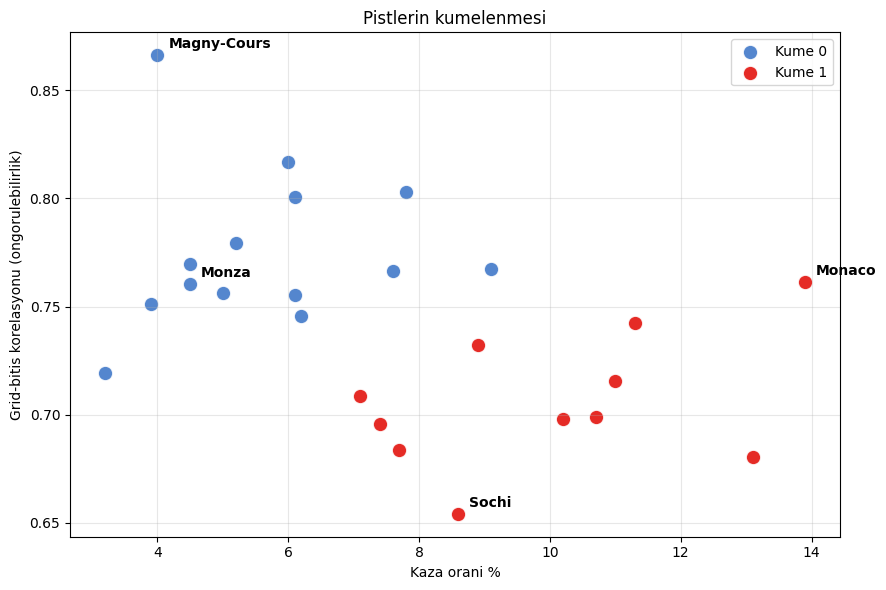

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
renkler = ["#3671C6", "#E10600", "#FF8000", "#2ECC8F"]

for k in sorted(pist["kume"].unique()):
    alt = pist[pist["kume"] == k]
    ax.scatter(alt["kaza_orani"], alt["grid_finish_korelasyon"],
               s=110, color=renkler[k % len(renkler)],
               label=f"Kume {k}", alpha=0.85, edgecolors="white", linewidth=1)

for isim in ["Monaco", "Monza", "Sochi", "Magny-Cours"]:
    satir = pist[pist["circuit_name"].str.contains(isim)]
    if len(satir):
        ax.annotate(isim,
                    (satir["kaza_orani"].iloc[0], satir["grid_finish_korelasyon"].iloc[0]),
                    xytext=(8, 5), textcoords="offset points", fontsize=10, weight="bold")

ax.set_xlabel("Kaza orani %")
ax.set_ylabel("Grid-bitis korelasyonu (ongorulebilirlik)")
ax.set_title("Pistlerin kumelenmesi")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## B4. DBSCAN — aykırı pist var mı?

K-Means'in bir zorunluluğu var: **her noktayı** bir kümeye atamak zorunda.
Grubun dışında kalan tuhaf bir pist olsa bile en yakın kümeye zorla sokuyor.

DBSCAN böyle yapmıyor. Yoğunluk temelli çalışıyor: etrafında yeterince komşusu
olmayan noktaları `-1` etiketiyle **aykırı** işaretliyor ve hiçbir kümeye
koymuyor.

İki parametresi var:
- **eps** — "komşu" sayılmak için gereken en fazla uzaklık
- **min_samples** — bir noktanın çekirdek sayılması için gereken komşu sayısı

### eps'i nasıl seçeriz?

Standart yöntem **k-uzaklık grafiği**: her nokta için `min_samples`inci en yakın
komşusunun uzaklığını hesapla, küçükten büyüğe sırala, çiz.

Grafiğin sonunda yukarı doğru keskin bir kıvrılma olur — orada duran noktalar
komşularından uzakta olanlar, yani aykırı adayları. Kıvrılmanın başladığı
yükseklik iyi bir eps değeridir.

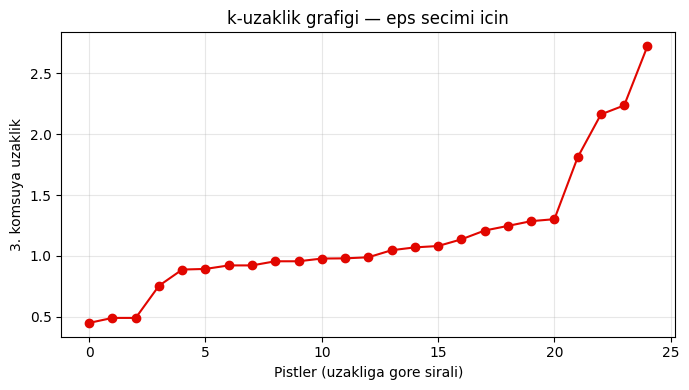

Siralanmis uzakliklar:
[0.45 0.49 0.49 0.75 0.89 0.89 0.92 0.92 0.95 0.95 0.98 0.98 0.99 1.05
 1.07 1.08 1.14 1.21 1.25 1.28 1.3  1.81 2.16 2.24 2.72]


In [ ]:
MIN_SAMPLES = 3

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
mesafeler, _ = nn.kneighbors(X)
sirali = np.sort(mesafeler[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sirali, "o-", color="#E10600")
ax.set_xlabel("Pistler (uzakliga gore sirali)")
ax.set_ylabel(f"{MIN_SAMPLES}. komsuya uzaklik")
ax.set_title("k-uzaklik grafigi — eps secimi icin")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Siralanmis uzakliklar:")
print(np.round(sirali, 2))

In [ ]:
# eps degistikce ne oluyor? Parametrenin etkisini gormek icin tarama.
print(f"{'eps':>5} {'kume':>6} {'aykiri':>7}  aykiri pistler")
for eps in [0.8, 1.0, 1.2, 1.4, 1.6, 1.8]:
    etiketler = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X)
    kume_sayisi = len(set(etiketler)) - (1 if -1 in etiketler else 0)
    aykirilar = pist.loc[etiketler == -1, "circuit_name"].tolist()
    print(f"{eps:5.1f} {kume_sayisi:6d} {sum(etiketler == -1):7d}  "
          f"{', '.join(aykirilar) if aykirilar else '-'}")

  eps   kume  aykiri  aykiri pistler
  0.8      2      17  Circuit de Nevers Magny-Cours, Baku City Circuit, Autodromo Enzo e Dino Ferrari, Sochi Autodrom, Autódromo Hermanos Rodríguez, Nürburgring, Hockenheimring, Marina Bay Street Circuit, Sepang International Circuit, Suzuka Circuit, Circuit Gilles Villeneuve, Circuit de Spa-Francorchamps, Albert Park Grand Prix Circuit, Autódromo José Carlos Pace, Circuit de Monaco, Circuit de Barcelona-Catalunya, Silverstone Circuit
  1.0      4       5  Circuit de Nevers Magny-Cours, Sochi Autodrom, Circuit Gilles Villeneuve, Albert Park Grand Prix Circuit, Circuit de Monaco
  1.2      3       5  Circuit de Nevers Magny-Cours, Sochi Autodrom, Circuit Gilles Villeneuve, Albert Park Grand Prix Circuit, Circuit de Monaco
  1.4      1       3  Circuit de Nevers Magny-Cours, Albert Park Grand Prix Circuit, Circuit de Monaco
  1.6      1       1  Albert Park Grand Prix Circuit
  1.8      1       0  -


Tabloda mantığı görebiliyorsun: eps küçükken neredeyse her şey aykırı sayılıyor,
eps büyüdükçe her şey tek kümeye toplanıyor ve aykırı kalmıyor. İkisinin arasında
anlamlı bir bölge var.

k-uzaklık grafiğindeki kıvrılma yüksekliğine yakın bir eps seç ve aşağıya yaz.

In [ ]:
SECILEN_EPS = 1.2   # k-uzaklik grafigine bakip guncelle

db = DBSCAN(eps=SECILEN_EPS, min_samples=MIN_SAMPLES)
pist["dbscan"] = db.fit_predict(X)

print("Etiket dagilimi (-1 = aykiri):")
print(pist["dbscan"].value_counts().sort_index().to_string())

aykiri = pist[pist["dbscan"] == -1]
if len(aykiri):
    print("\nAykiri isaretlenen pistler:")
    print(aykiri[["circuit_name"] + OZ].to_string(index=False))
else:
    print("\nAykiri pist yok - eps'i kucultup tekrar dene.")

Etiket dagilimi (-1 = aykiri):
dbscan
-1     5
 0     4
 1    13
 2     3

Aykiri isaretlenen pistler:
                  circuit_name  grid_finish_korelasyon  kaza_orani  dnf_orani  ort_pozisyon_degisimi
 Circuit de Nevers Magny-Cours                  0.8662         4.0       18.5                   2.94
                Sochi Autodrom                  0.6542         8.6       17.2                   3.91
     Circuit Gilles Villeneuve                  0.6979        10.2       27.1                   4.35
Albert Park Grand Prix Circuit                  0.6806        13.1       33.0                   4.52
             Circuit de Monaco                  0.7614        13.9       27.3                   3.82


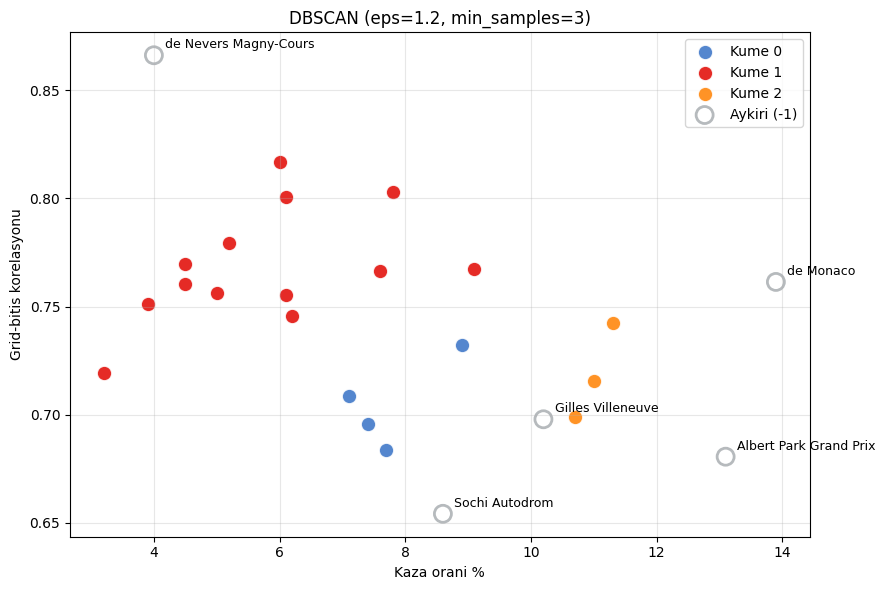

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

normal = pist[pist["dbscan"] != -1]
aykiri = pist[pist["dbscan"] == -1]

for k in sorted(normal["dbscan"].unique()):
    alt = normal[normal["dbscan"] == k]
    ax.scatter(alt["kaza_orani"], alt["grid_finish_korelasyon"],
               s=110, color=renkler[k % len(renkler)], label=f"Kume {k}",
               alpha=0.85, edgecolors="white", linewidth=1)

ax.scatter(aykiri["kaza_orani"], aykiri["grid_finish_korelasyon"],
           s=150, color="none", edgecolors="#B6BABD", linewidth=2,
           marker="o", label="Aykiri (-1)")

for _, satir in aykiri.iterrows():
    ax.annotate(satir["circuit_name"].replace("Circuit", "").strip(),
                (satir["kaza_orani"], satir["grid_finish_korelasyon"]),
                xytext=(8, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Kaza orani %")
ax.set_ylabel("Grid-bitis korelasyonu")
ax.set_title(f"DBSCAN (eps={SECILEN_EPS}, min_samples={MIN_SAMPLES})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## B5. İki yöntemin karşılaştırması

In [ ]:
karsilastirma = pist[["circuit_name", "kume", "dbscan"]].copy()
karsilastirma.columns = ["Pist", "K-Means", "DBSCAN"]
print(karsilastirma.sort_values(["K-Means", "DBSCAN"]).to_string(index=False))

                          Pist  K-Means  DBSCAN
 Circuit de Nevers Magny-Cours        0      -1
 Autodromo Enzo e Dino Ferrari        0       1
  Autódromo Hermanos Rodríguez        0       1
                 Istanbul Park        0       1
       Circuit of the Americas        0       1
                 Red Bull Ring        0       1
            Yas Marina Circuit        0       1
Shanghai International Circuit        0       1
                Suzuka Circuit        0       1
 Bahrain International Circuit        0       1
Circuit de Barcelona-Catalunya        0       1
                   Hungaroring        0       1
  Autodromo Nazionale di Monza        0       1
           Silverstone Circuit        0       1
                Sochi Autodrom        1      -1
     Circuit Gilles Villeneuve        1      -1
Albert Park Grand Prix Circuit        1      -1
             Circuit de Monaco        1      -1
             Baku City Circuit        1       0
                   Nürburgring        1 

| | K-Means | DBSCAN |
|---|---|---|
| Küme sayısı | Sen söylersin | Algoritma bulur |
| Aykırı değer | Yok, herkes bir kümede | `-1` ile işaretlenir |
| Parametre | k | eps, min_samples |
| Küme şekli | Yuvarlak varsayar | Serbest |

İkisi de aynı veriye bakıyor ama farklı sorular soruyor. K-Means "bu pistler kaç
gruba ayrılır" diyor, DBSCAN "hangi pistler diğerlerine benzemiyor" diyor.

---
# Özet

**Bölüm A — Sınıflandırma**

1. Accuracy bu problemde yanıltıcı; hiçbir şey tahmin etmeyen model bile yüksek
   accuracy alıyor. Karışıklık matrisi olmadan model değerlendirilemez.
2. Sadece grid kullanan model, tek kurallı baseline'a çok yakın. Grid pozisyonu
   sonucun omurgası.
3. Form ölçülebilir ama küçük katkı yapıyor; grid olmadan tek başına çok daha zayıf.
4. Katsayılar da aynı şeyi söylüyor: grid'in ağırlığı iki form değişkeninin
   toplamından yüksek.

**Bölüm B — Kümeleme**

5. Pistler kendiliğinden gruplara ayrılıyor ve **Monaco ile Monza farklı gruplara
   düşüyor** — öngörülebilirlikleri neredeyse aynı olmasına rağmen. H4'te elle
   bulduğumuz ayrımı algoritma biz söylemeden buldu.
6. DBSCAN birkaç pisti aykırı işaretliyor: ya aşırı öngörülebilir ya aşırı kaotik
   olanlar.

Sunumda söylenecek cümle: *"Bu ayrımı ben seçmedim. Dört özellik verdim, algoritma
pistleri gruplara ayırdı ve Monaco ile Monza'yı farklı gruplara koydu."*